# Multivariate Analysis

- **Cramér's V** and **Phi² test** for relationships between **categorical  variables** (binary included).  
- **Pearson correlation** for assessing associations between **numerical variables**.  
- **ANOVA** for examining differences between **numeric variables and categorical variables**.  
- **T-test** for comparing **numeric variables with binary variables**.  
- **Small follow-up visualizations** to support statistical findings.


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway, ttest_ind

import sys
sys.path.append('..')

from scripts.constants import *


## Read Dataset

In [2]:
data = pd.read_csv("../data/interim/05. FRAIL_correct_dtypes.csv")
print(data.shape)
data.head()

(6845, 85)


,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,...,MMSE_LINGUAGEM_D_LEITURA,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_CUIDADOS_PESSOAIS,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100
0,19,1,1,2021-11-16,1941-08-20,80.0,0,1.0,2.0,153.0,...,1.0,1.0,0.0,16.0,1.0,1.0,1.0,1.0,2.0,80.0
1,19,3,1,2022-11-16,1941-08-20,81.0,0,1.0,2.0,152.0,...,1.0,1.0,0.0,20.0,2.0,2.0,2.0,2.0,1.0,80.0
2,19,4,1,2023-06-20,1941-08-20,81.0,0,1.0,2.0,153.0,...,0.0,1.0,0.0,16.0,1.0,1.0,1.0,2.0,1.0,90.0
3,37,1,1,2021-11-16,1948-11-20,72.0,0,1.0,2.0,149.0,...,1.0,1.0,0.0,20.0,1.0,1.0,1.0,1.0,2.0,100.0
4,37,2,1,2022-06-29,1948-11-20,73.0,0,1.0,2.0,150.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0


## Binary and categorical variables

In [3]:
binary_and_categorical = binary_columns + nominal_columns
numerical = numerical_columns + discrete_columns + ordinal_columns

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

def phi2(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    return phi2

### Crammers

/tmp/ipykernel_9118/1394795313.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / min(k - 1, r - 1))
/tmp/ipykernel_9118/1394795313.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / min(k - 1, r - 1))


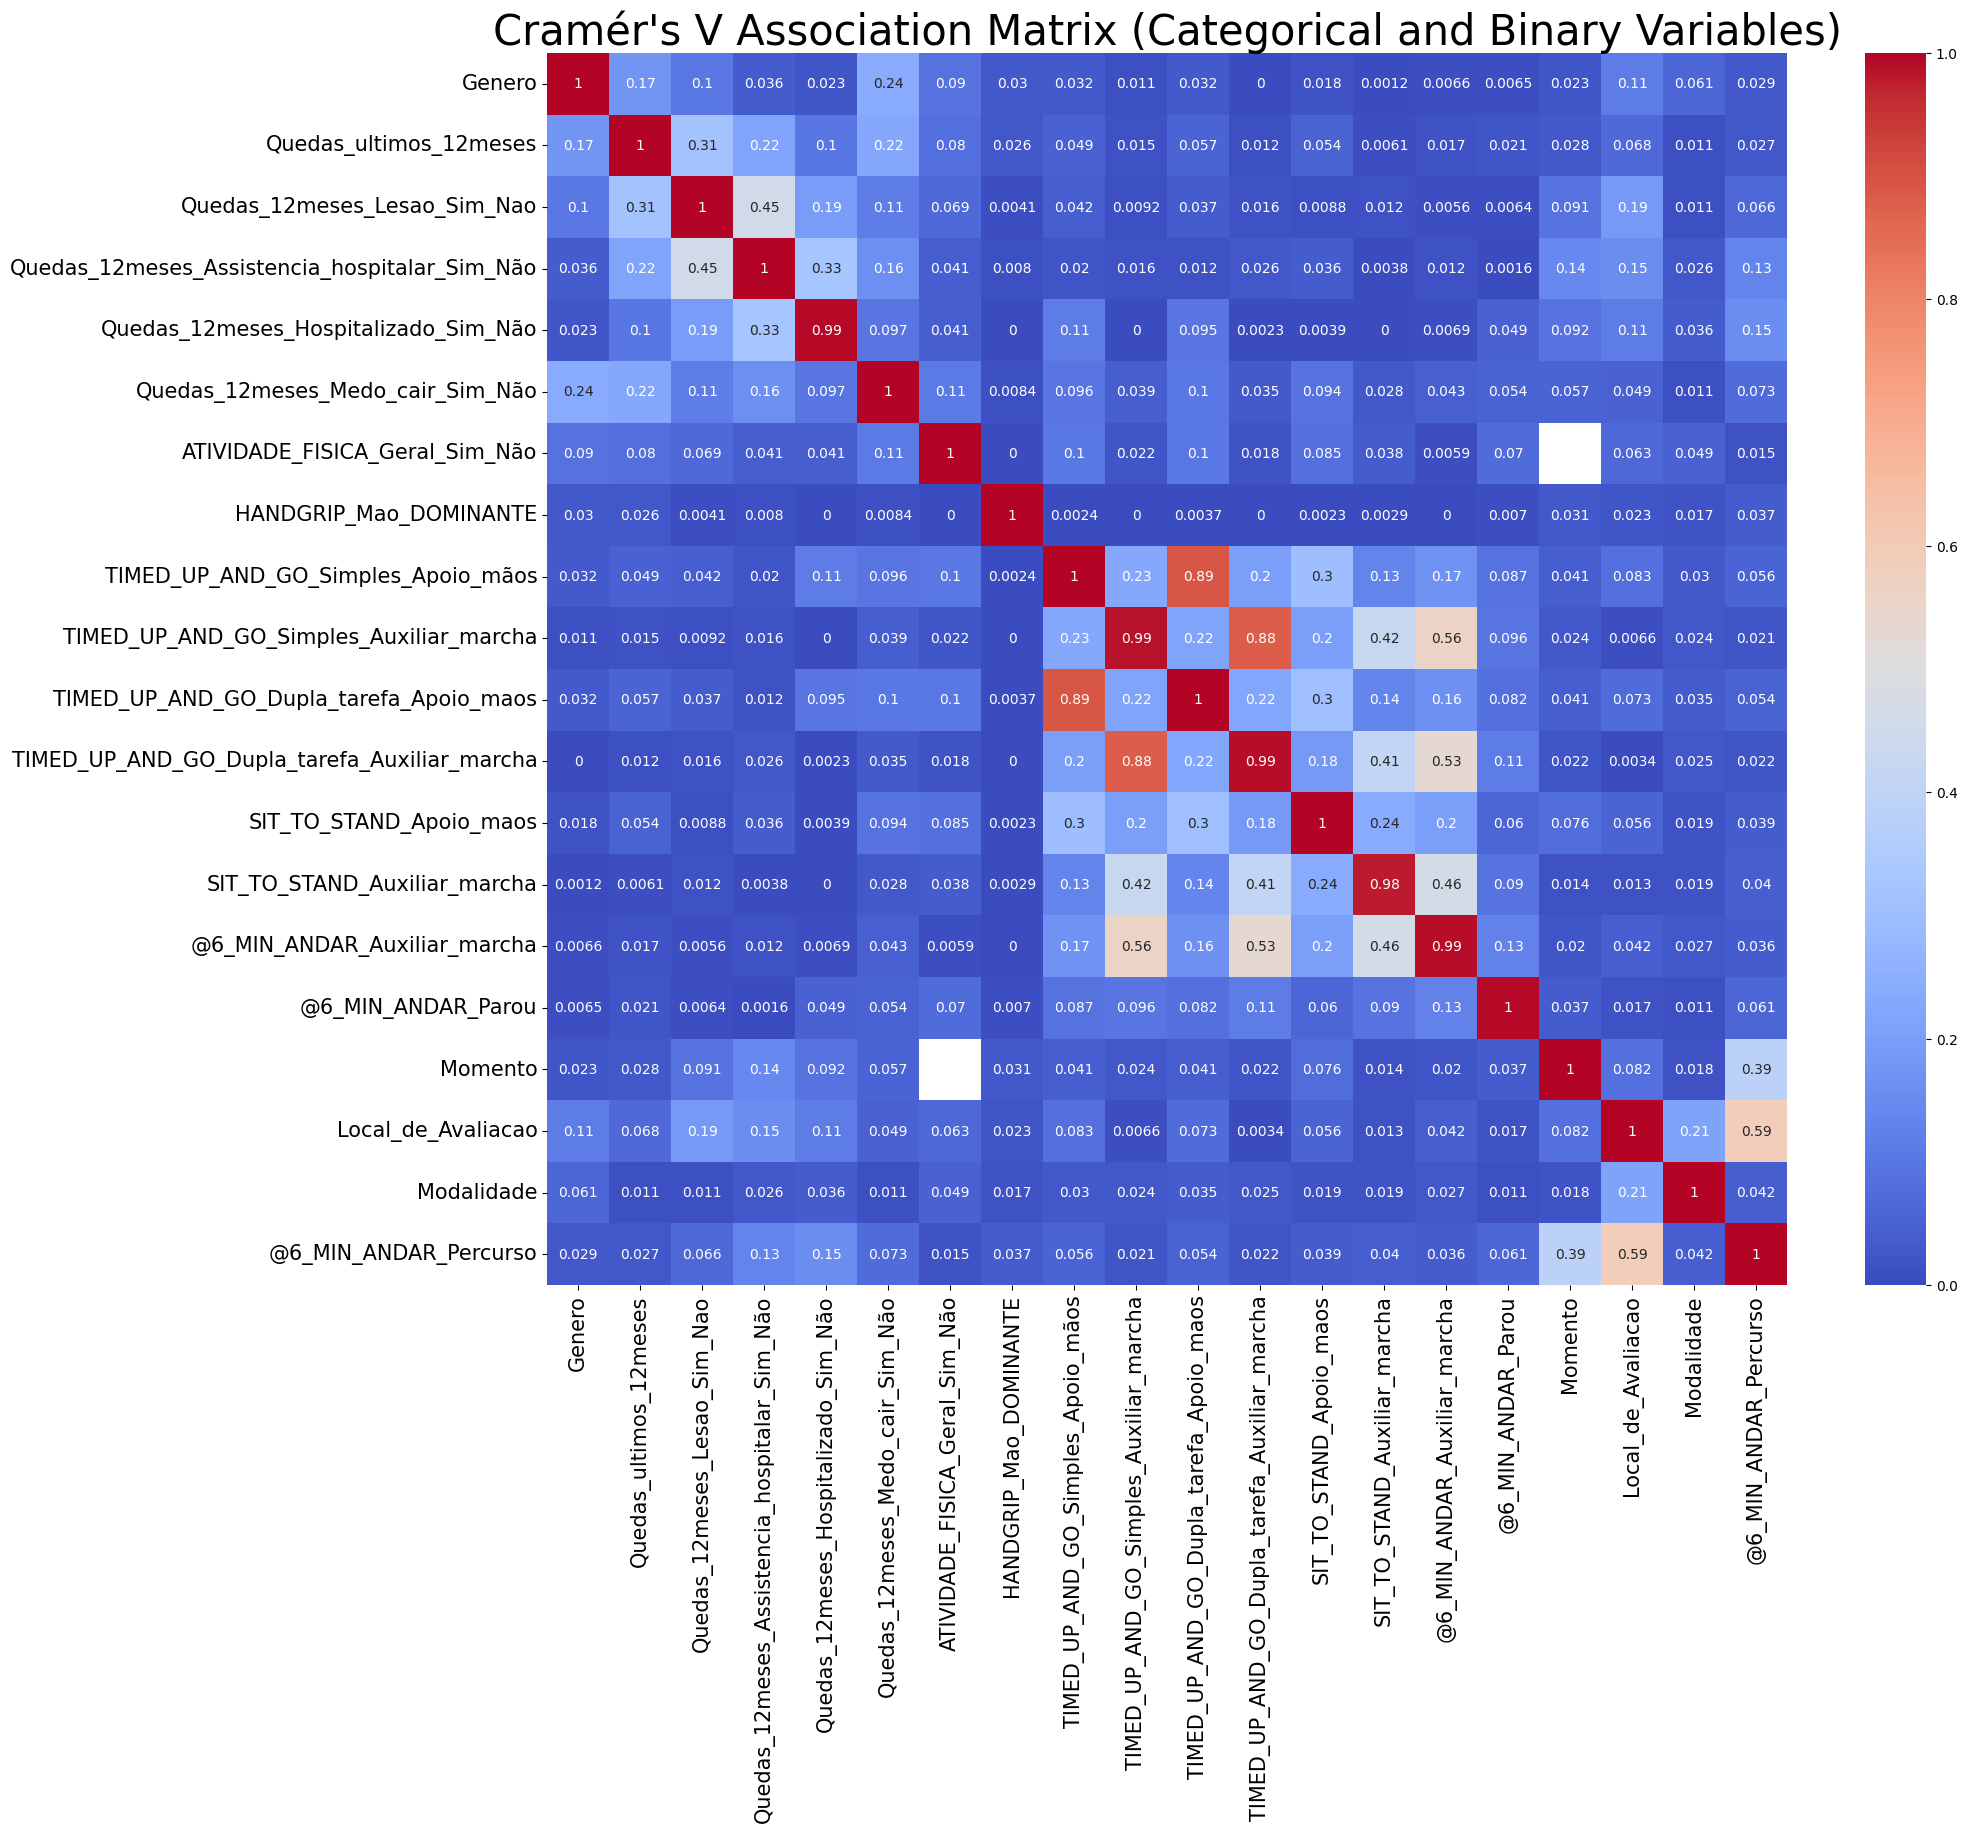

In [4]:
# Prepare empty matrix
n = len(binary_and_categorical)
cramers_matrix = pd.DataFrame(np.zeros((n, n)), index=binary_and_categorical, columns=binary_and_categorical)

# Calculate Cramér's V for each pair
for col1 in binary_and_categorical:
    for col2 in binary_and_categorical:
        cramers_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

# Plot heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(cramers_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V Association Matrix (Categorical and Binary Variables)", fontsize=30)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

### Phi^2

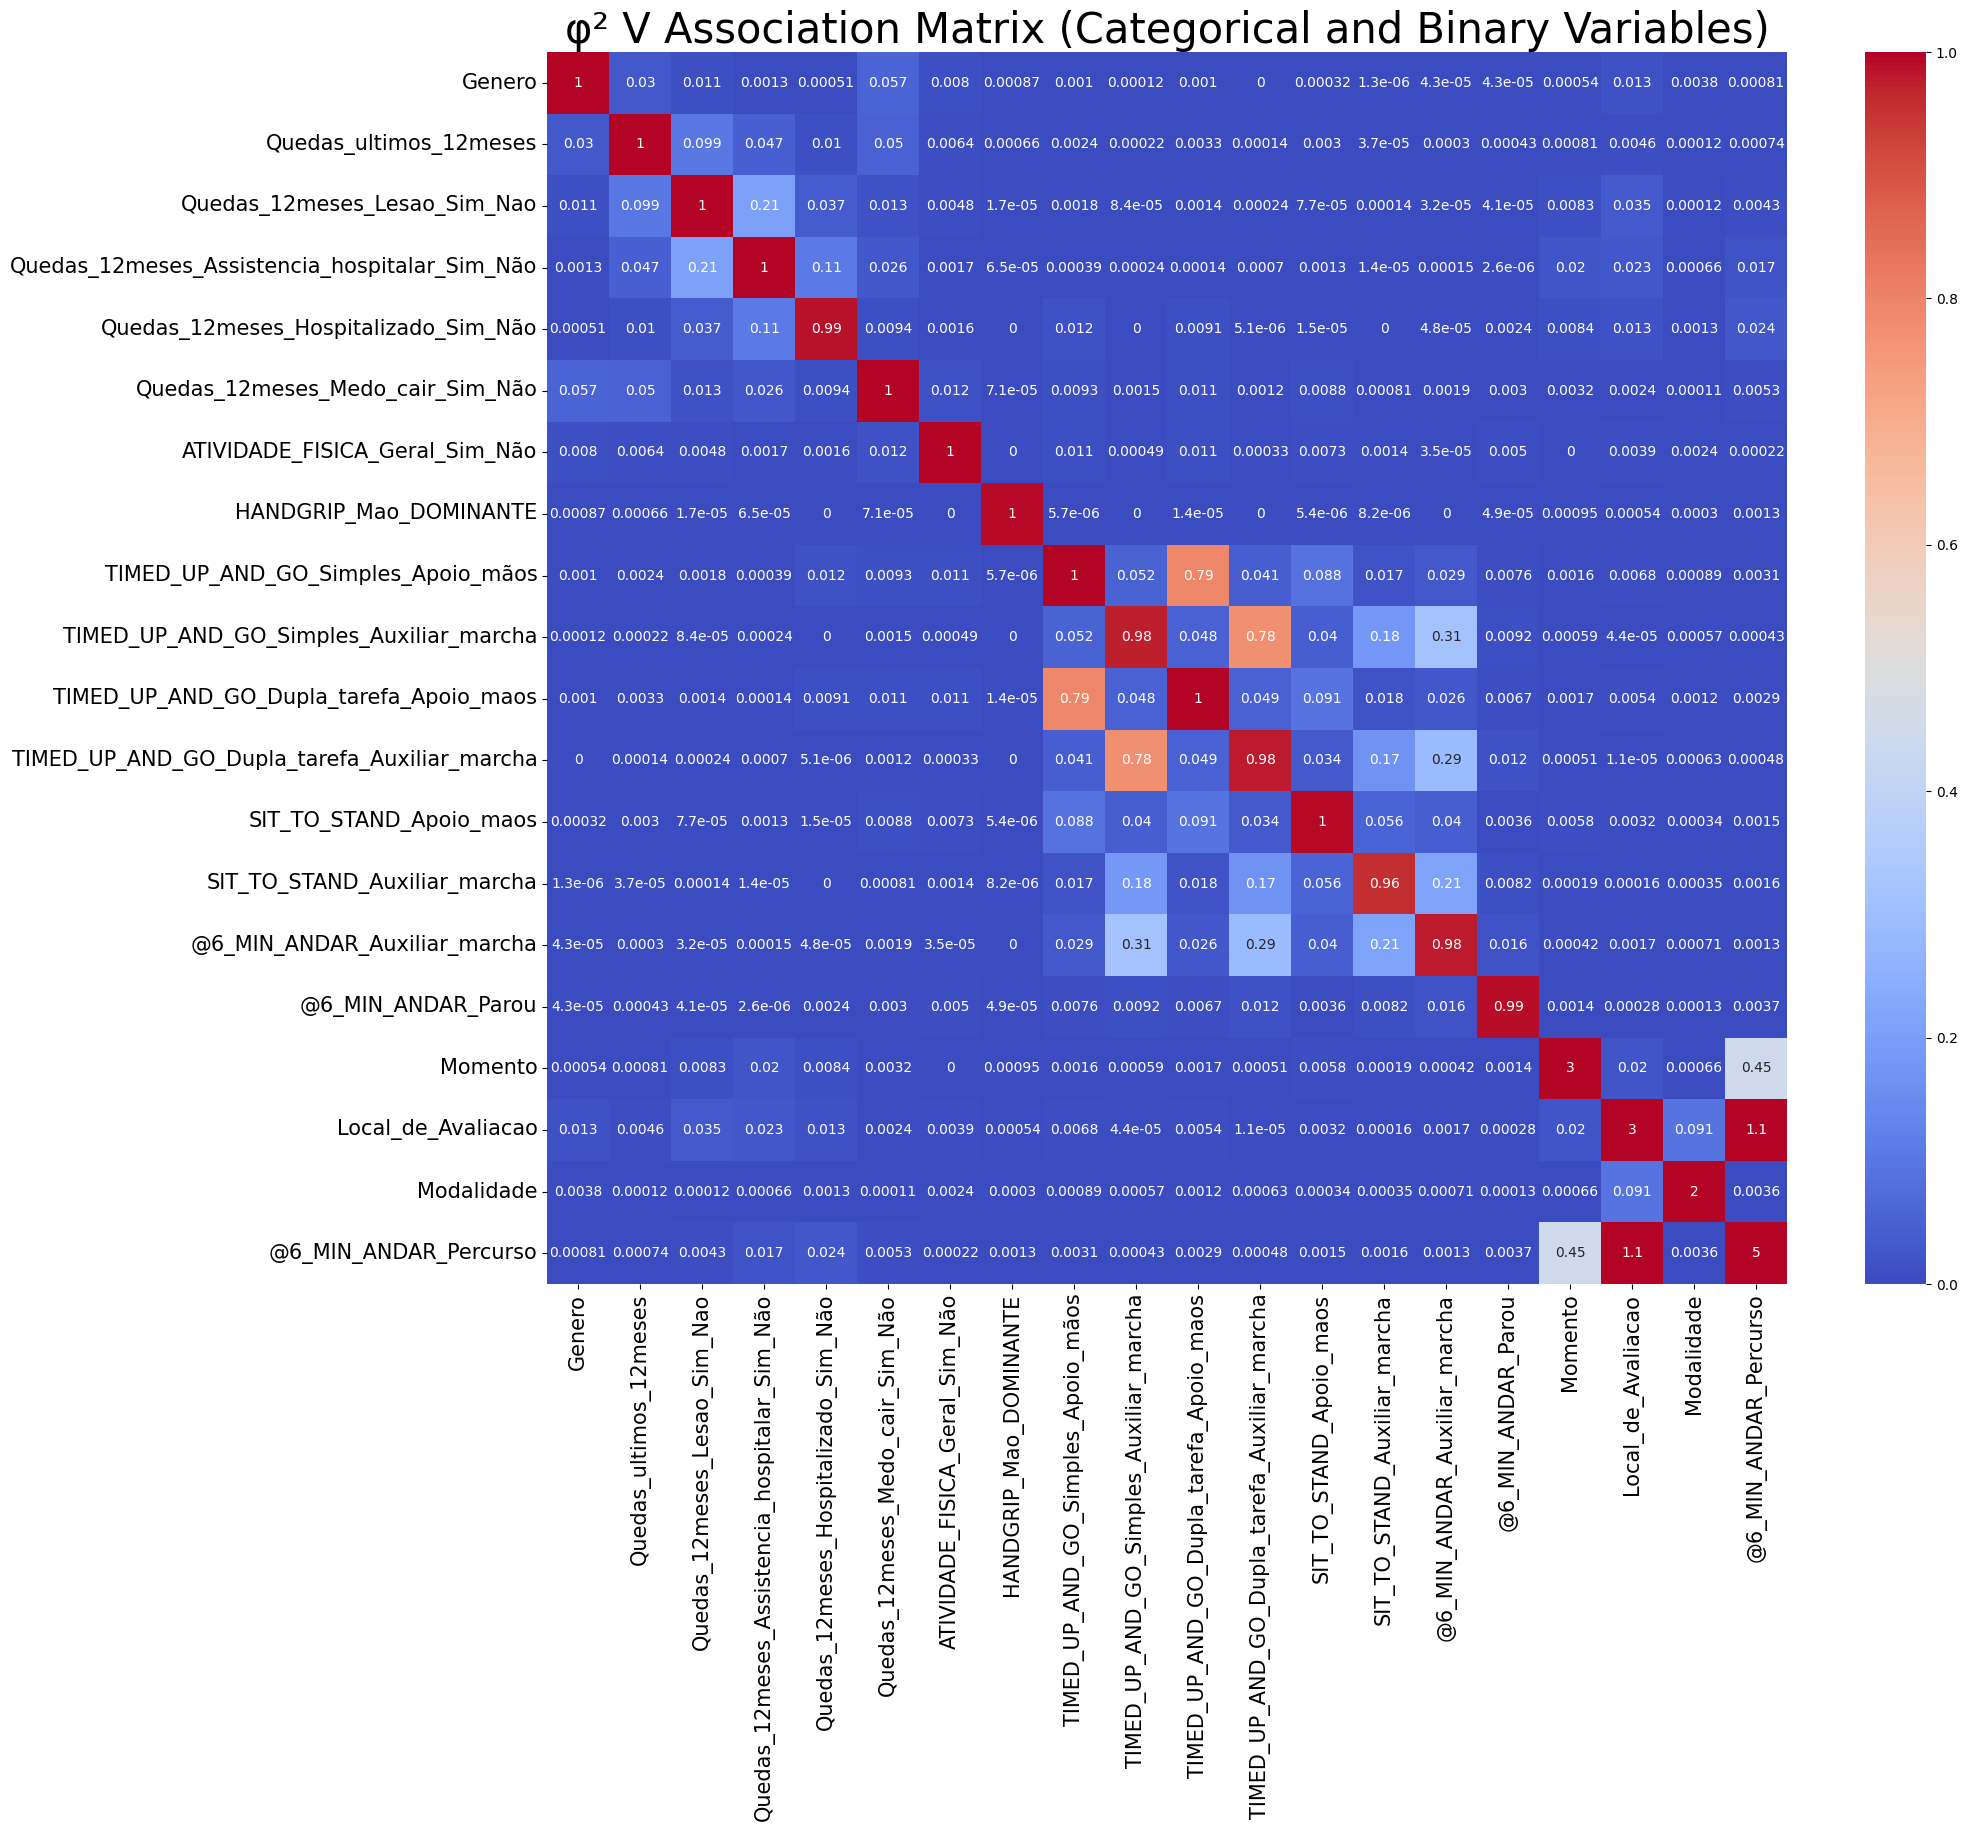

In [5]:
# Prepare empty matrix
n = len(binary_and_categorical)
cramers_matrix = pd.DataFrame(np.zeros((n, n)), index=binary_and_categorical, columns=binary_and_categorical)

# Calculate Cramér's V for each pair
for col1 in binary_and_categorical:
    for col2 in binary_and_categorical:
        cramers_matrix.loc[col1, col2] = phi2(data[col1], data[col2])

# Plot heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(cramers_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("φ² V Association Matrix (Categorical and Binary Variables)", fontsize=30)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

## Numerical variables

### Pearsons

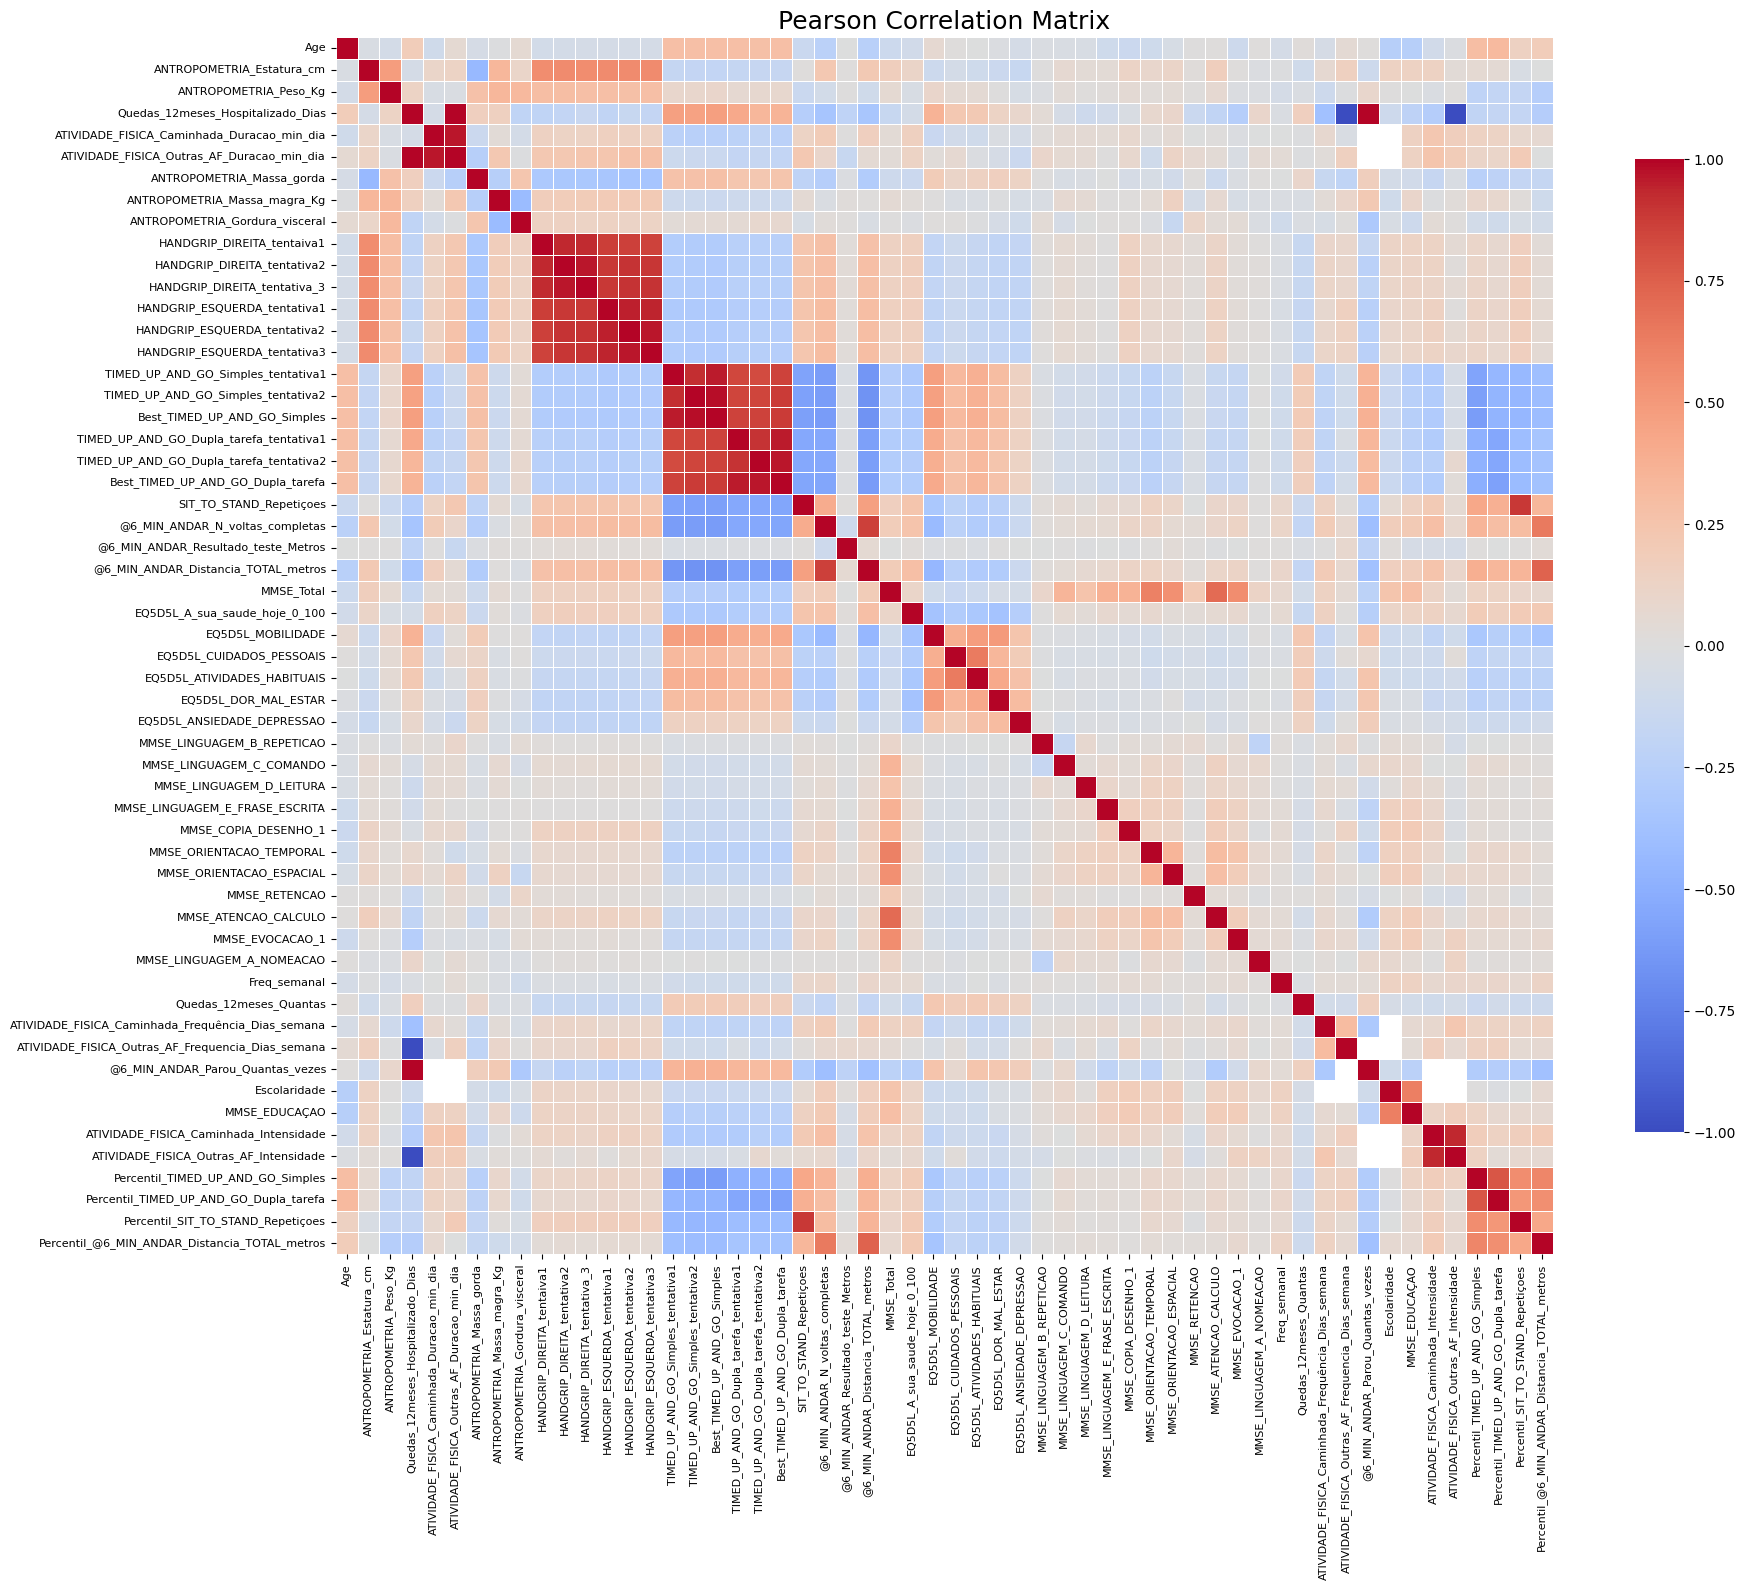

In [6]:
corr_matrix = data[numerical].corr(method='pearson')

# Plot the correlation heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            annot=False, 
            fmt='.2f', 
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

# Customize font sizes
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8)
plt.title("Pearson Correlation Matrix", fontsize=18)
plt.tight_layout()
plt.show()

## Numeric with categorical and binary

### ANOVA (numeric - non binary categorical)

In [7]:
anova_results = []

for cat_var in nominal_columns:
    for num_var in numerical:
        # Drop NA for both columns
        subset = data[[cat_var, num_var]].dropna()

        # Get groups (numeric values split by categorical variable)
        groups = [group[num_var].values for name, group in subset.groupby(cat_var)]

        # Only proceed if there are at least 2 groups
        if len(groups) >= 2 and all(len(g) > 1 for g in groups):
            f_stat, p_val = f_oneway(*groups)
            anova_results.append({
                'Categorical Variable': cat_var,
                'Numeric Variable': num_var,
                'F-statistic': f_stat,
                'p-value': p_val
            })

# Convert to DataFrame
anova_df = pd.DataFrame(anova_results)

# Optional: sort by p-value to see most significant effects
anova_df = anova_df.sort_values(by='p-value')

# Show results
anova_df.head(10)

,Categorical Variable,Numeric Variable,F-statistic,p-value
146,Modalidade,Freq_semanal,6099.561394,0.000000e+00
57,Local_de_Avaliacao,ANTROPOMETRIA_Gordura_visceral,727.781081,0.000000e+00
6,Momento,ANTROPOMETRIA_Gordura_visceral,283.190045,3.073120e-170
180,@6_MIN_ANDAR_Percurso,@6_MIN_ANDAR_N_voltas_completas,150.916707,6.105983e-152
165,@6_MIN_ANDAR_Percurso,ANTROPOMETRIA_Massa_magra_Kg,131.976031,2.631311e-133
56,Local_de_Avaliacao,ANTROPOMETRIA_Massa_magra_Kg,177.781372,7.643896e-111
166,@6_MIN_ANDAR_Percurso,ANTROPOMETRIA_Gordura_visceral,80.646054,1.608682e-81
92,Local_de_Avaliacao,Freq_semanal,123.142316,1.114581e-77
71,Local_de_Avaliacao,@6_MIN_ANDAR_N_voltas_completas,115.482821,6.247125e-73
101,Local_de_Avaliacao,Percentil_TIMED_UP_AND_GO_Dupla_tarefa,107.002322,1.087763e-67


### T-test (numeric - binary)

In [8]:
t_test_results = []

for cat_var in binary_columns:
    # Check if categorical variable has exactly 2 levels
    if data[cat_var].nunique() != 2:
        continue

    for num_var in numerical:
        subset = data[[cat_var, num_var]].dropna()

        # Get the two groups
        levels = subset[cat_var].unique()
        if len(levels) > 1:
            group1 = subset[subset[cat_var] == levels[0]][num_var]
            group2 = subset[subset[cat_var] == levels[1]][num_var]
        else:
            print(cat_var)
            continue

        if len(group1) > 1 and len(group2) > 1:
            if len(group1) > 1 and len(group2) > 1 and group1.std() > 0 and group2.std() > 0:
                stat, pval = ttest_ind(group1, group2, equal_var=False)
            t_test_results.append({
                'Categorical Variable': cat_var,
                'Numeric Variable': num_var,
                't-statistic': stat,
                'p-value': pval
            })

# Convert to DataFrame
t_test_df = pd.DataFrame(t_test_results).sort_values('p-value')
t_test_df.head(10)

Quedas_ultimos_12meses
ATIVIDADE_FISICA_Geral_Sim_Não
TIMED_UP_AND_GO_Simples_Auxiliar_marcha
TIMED_UP_AND_GO_Simples_Auxiliar_marcha
TIMED_UP_AND_GO_Simples_Auxiliar_marcha
TIMED_UP_AND_GO_Simples_Auxiliar_marcha
TIMED_UP_AND_GO_Dupla_tarefa_Auxiliar_marcha
SIT_TO_STAND_Auxiliar_marcha
SIT_TO_STAND_Auxiliar_marcha
SIT_TO_STAND_Auxiliar_marcha
SIT_TO_STAND_Auxiliar_marcha
@6_MIN_ANDAR_Auxiliar_marcha


,Categorical Variable,Numeric Variable,t-statistic,p-value
13,Genero,HANDGRIP_ESQUERDA_tentativa2,-55.682766,0.000000e+00
1,Genero,ANTROPOMETRIA_Estatura_cm,-81.742456,0.000000e+00
6,Genero,ANTROPOMETRIA_Massa_gorda,53.231993,0.000000e+00
9,Genero,HANDGRIP_DIREITA_tentaiva1,-51.007951,0.000000e+00
10,Genero,HANDGRIP_DIREITA_tentativa2,-53.414045,0.000000e+00
11,Genero,HANDGRIP_DIREITA_tentativa_3,-53.238337,0.000000e+00
12,Genero,HANDGRIP_ESQUERDA_tentativa1,-54.833184,0.000000e+00
14,Genero,HANDGRIP_ESQUERDA_tentativa3,-55.306068,0.000000e+00
378,ATIVIDADE_FISICA_Geral_Sim_Não,ATIVIDADE_FISICA_Caminhada_Frequência_Dias_semana,48.131173,3.214031e-259
2,Genero,ANTROPOMETRIA_Peso_Kg,-29.614044,1.925777e-175


## Further analysis

<Axes: xlabel='Age', ylabel='Count'>

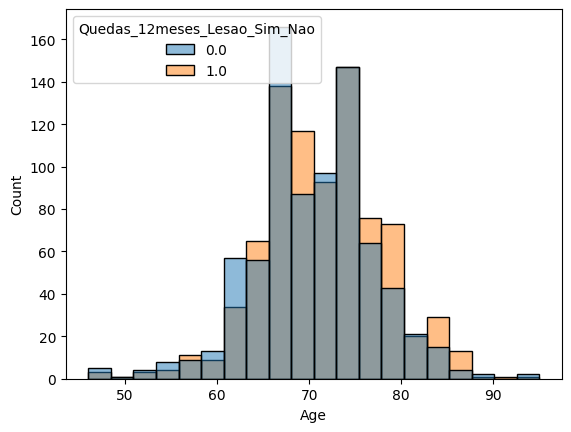

In [9]:
sns.histplot(data=data, x="Age", hue="Quedas_12meses_Lesao_Sim_Nao", bins = 20)